In this notebook, I implement both SVM Classification (SVC) and SVM Regression (SVR) using NumPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from svm_classifier import MySVMClassifier
from svm_regressor import MySVMRegressor

We use a linear SVM to separate two blobs. The key feature of SVM is the **Margin**.

In [2]:
# Generate Data
X, y = datasets.make_blobs(n_samples=50, n_features=2, centers=2, cluster_std=1.05, random_state=40)
# Convert 0/1 labels to -1/1 for SVM math
y = np.where(y == 0, -1, 1)

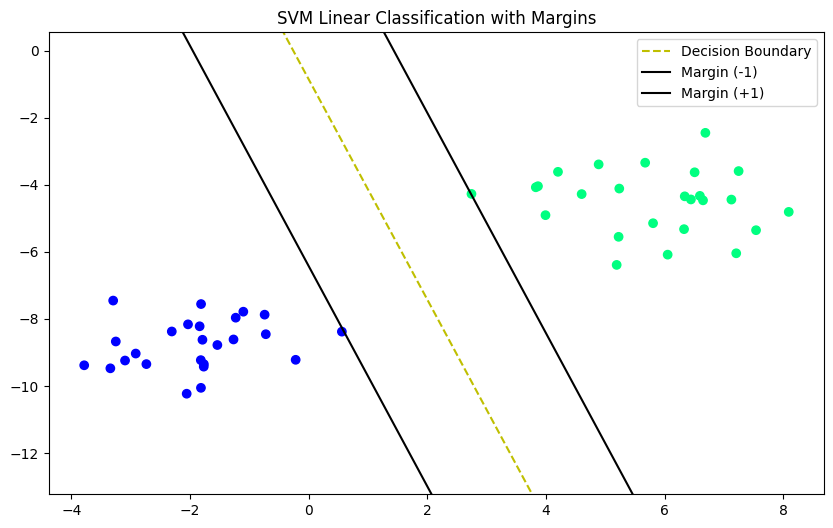

In [3]:
# Train Model
clf = MySVMClassifier(learning_rate=0.001, lambda_param=0.01, n_iterations=1000)
clf.fit(X, y)

def visualize_svm():
    def get_hyperplane_value(x, w, b, offset):
        return (-w[0] * x + b + offset) / w[1]
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, cmap='winter')
    x0_1 = np.amin(X[:, 0])
    x0_2 = np.amax(X[:, 0])

    x1_1 = get_hyperplane_value(x0_1, clf.w, clf.b, 0)
    x1_2 = get_hyperplane_value(x0_2, clf.w, clf.b, 0)
    x1_1_m = get_hyperplane_value(x0_1, clf.w, clf.b, -1)
    x1_2_m = get_hyperplane_value(x0_2, clf.w, clf.b, -1)

    x1_1_p = get_hyperplane_value(x0_1, clf.w, clf.b, 1)
    x1_2_p = get_hyperplane_value(x0_2, clf.w, clf.b, 1)
    ax.plot([x0_1, x0_2], [x1_1, x1_2], 'y--', label='Decision Boundary')
    ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], 'k', label='Margin (-1)')
    ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], 'k', label='Margin (+1)')
    x1_min = np.amin(X[:, 1])
    x1_max = np.amax(X[:, 1])
    ax.set_ylim([x1_min - 3, x1_max + 3])
    plt.title('SVM Linear Classification with Margins')
    plt.legend()
    plt.show()
visualize_svm()

## Part 2: SVM Regression (SVR)

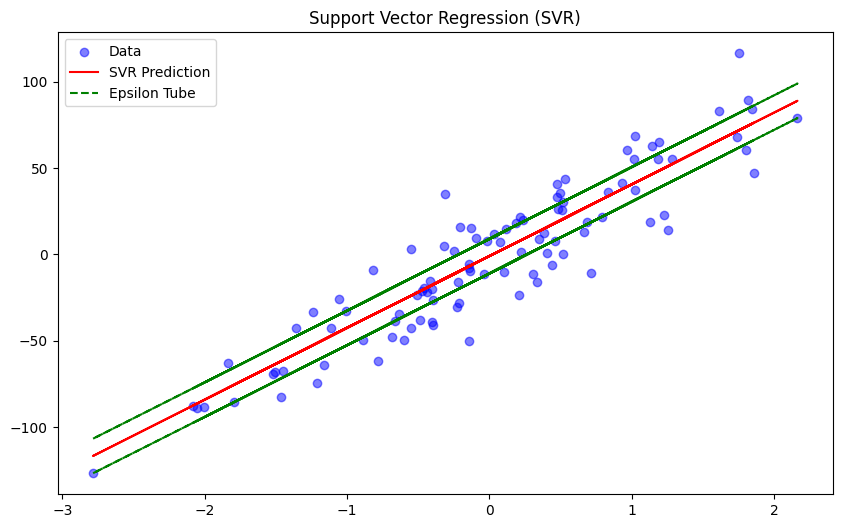

In [4]:
# Generate Regression Data
X_reg, y_reg = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# Scale Data (Crucial for Gradient Descent)
X_reg = (X_reg - X_reg.mean()) / X_reg.std()

# Train SVR
reg = MySVMRegressor(learning_rate=0.01, n_iterations=1000, epsilon=10)
reg.fit(X_reg, y_reg)

plt.figure(figsize=(10,6))
plt.scatter(X_reg, y_reg, color='blue', alpha=0.5, label='Data')
plt.plot(X_reg, reg.predict(X_reg), color='red', label='SVR Prediction')

# Visualize the Epsilon Tube
plt.plot(X_reg, reg.predict(X_reg) + reg.epsilon, color='green', linestyle='--', label='Epsilon Tube')
plt.plot(X_reg, reg.predict(X_reg) - reg.epsilon, color='green', linestyle='--')

plt.title("Support Vector Regression (SVR)")
plt.legend()
plt.show()